In [3]:
import os.path as osp
from alseg.utils import Browser
from alseg.utils import StrategyFigure

LOGS_PATH = osp.join("logs")

CLASS_NAMES = ('road', 'sidewalk', 'building', 'wall', 'fence', 'pole',
               'traffic light', 'traffic sign', 'vegetation', 'terrain',
               'sky', 'person', 'rider', 'car', 'truck', 'bus', 'train',
               'motorcycle', 'bicycle')

In [ ]:
CONFIG_TRAIN = "deeplabv3_r18_cityscapes-344x688"
CONFIG_DAL = f"{CONFIG_TRAIN}_dal-300-150-6"

# (folder_name, display_name)
experiment_names = [
    ("Random", "Random"),
    ("ConformalRisk", "CRC-AL ($\\alpha = 0.05$, $\\tau = 0.5$)"),
]

seed_list = [42, 52, 62]

fig = StrategyFigure()
work_dir = osp.join(LOGS_PATH, CONFIG_TRAIN)
fig.add_full_training(Browser(work_dir))
for name in experiment_names:
    display_name = None
    if isinstance(name, tuple):
        name, display_name = name
    work_dir = osp.join(LOGS_PATH, CONFIG_DAL, name)
    fig.add_strategy(Browser(work_dir), seed_list, display_name)

params = dict(
    cls="all",
    cycles=(1, 6),
    show_std=True,
    show_percent=95,
    dataset_size=2975,
    show_initial_score=True,
    title="Cityscapes Dataset",
    p_value=0.05,
)

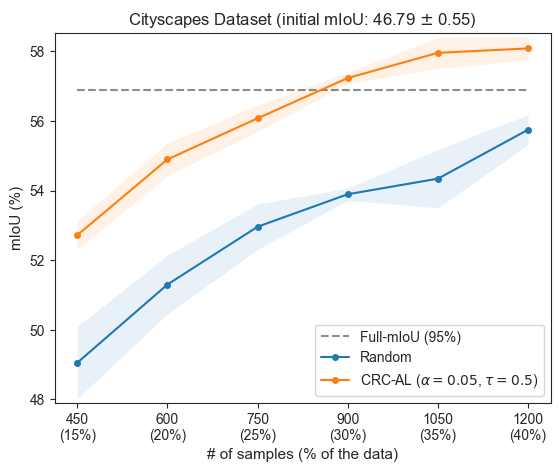

In [7]:
# Plot learning curves
fig.plot_curves(**params)

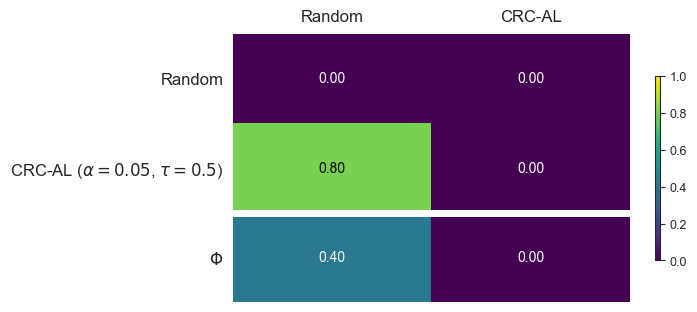

In [8]:
# Plot PPM (Pairwise Penalty Matrix)
fig.plot_ppm(**params)